<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-2/02_Dimensionality_Reduction/exercise_dimensionality_reduction_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: Dimensionality reduction algorithms

## Learning objectives
* apply PCA to a reduce the dimensionality of a high-dimensional dataset
* Select the optimal number of principal components
* repeat the exercise with IsoMap/tSNA/UMAP, and analyze how the projection depends on the model parameters

## 0. Imports and setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import Isomap
from sklearn.manifold import TSNE

np.random.seed(42)

## 1. Import and refine data

The array X includes the expression value of 2000 genes for 2700 cells obtained by single-cell RNAseq. The kind of the cell, as defined by known genetic markers, is reported in the array y.

In [22]:
data = np.load("/content/sample_data/data_pbmc.npz")
X = data["X"]
y = data["y"]

Remove from X and y all the cells that are labelled as 'Unknown'.
* How many cells are left ?
* Create an array, y_int, with the cell types converted into integer values, and an array, labels, with the list of cell types (Suggestion: use the function np.unique)

In [23]:
inds = y != 'Unknown'
X = X[inds,:] #filter out rows with 'Unknown' labels from the feature matrix X
y = y[inds]
labels, y_int = np.unique(y, return_inverse=True) #extract unique class names and map text labels to integer codes
print('Number of samples:', X.shape[0])
print('Possible cell types:', labels)

Number of samples: 2597
Possible cell types: ['B cells' 'Dendritic cells' 'Megakaryocytes' 'Monocytes' 'NK cells'
 'T cells']


## 2. Principal Component Analysis

* Project the data onto the first 50 principal components
* Plot the cumulative variance explained by the PCs
* Plot the data over the first 2 PCs using different markers (or colors) for the various cell kinds
* Compute the silhoutte score using the first 2 PCs and the labels in y_int. How do you interpret the silhoutte score in this case ?

In [24]:
n_pc = 50
pca = PCA(n_components = n_pc)
pca.fit(X) #fit the PCA model to calculate the orthogonal variance axes of data X
Xpca = pca.transform(X) #project the high-dimensional data into the lower-dimensional PCA subspace

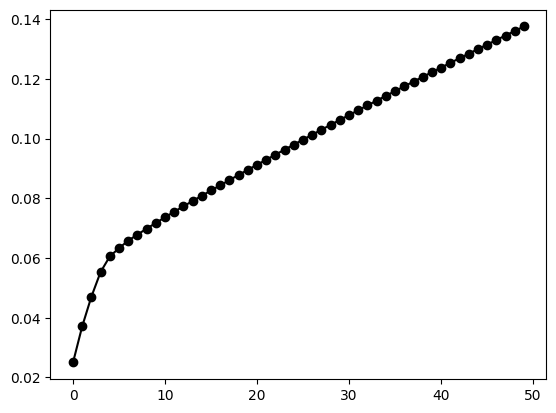

In [25]:
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(np.arange(n_pc), np.cumsum(pca.explained_variance_ratio_), '-ok') #plot the cumulative sum of explained variance ratio against the component indices

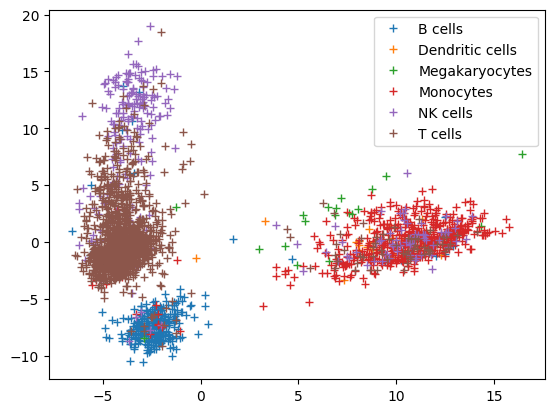

In [26]:
f = plt.figure()
ax = f.add_subplot(1,1,1)
for i_label, label in enumerate(labels): #loop through unique labels to plot each class with a different color
    inds = y_int == i_label #create a boolean mask for samples belonging to the current class index
    ax.plot(Xpca[inds,0], Xpca[inds,1], '+', label = label)
plt.legend()

In [27]:
sc = silhouette_score(Xpca[:,:2], y_int)
print('Silhoutte score with 2 PCs:', sc)

Silhoutte score with 2 PCs: 0.2711054691710063


## 3. Dimensionality reduction with IsoMap

* Use the IsoMap method to project the data over a 2-dimensional space starting from the original data X
* Change the value of the number of neighbors in the range from 5 to 20, and select the value that optimize the silhoutte score. Can you get a decent separation of the different cell types ?
* Repeat the previous points using as input the projection of the data over the first 50 principal components
* Select the number of neighbors that provides the highest silhoutte score
* Plot the data in the projected space using different colors for the various cell types

In [28]:
ns_neighbors = np.arange(5,21,2).astype(int) #define an array of neighbor sizes to evaluate
scores = np.zeros(len(ns_neighbors)) #initialize an array of zeros to store the silhouette score
for i, n_neighbors in enumerate(ns_neighbors): #loop through each neighbor value to fit Isomap
    iso = Isomap(n_components=2, n_neighbors=n_neighbors)
    Xiso = iso.fit_transform(X) #fit the manifold model and transform the high-dimensional data X into the 2D subspace
    scores[i] = silhouette_score(Xiso, y_int)
    print('Silhoutte score for IsoMap with n_neighbors {}: {}'.format(n_neighbors, scores[i]))

Silhoutte score for IsoMap with n_neighbors 5: 0.05732578724308137
Silhoutte score for IsoMap with n_neighbors 7: 0.09628081922941517
Silhoutte score for IsoMap with n_neighbors 9: 0.08943670094576998
Silhoutte score for IsoMap with n_neighbors 11: 0.06849154972278744
Silhoutte score for IsoMap with n_neighbors 13: 0.03749634259000977
Silhoutte score for IsoMap with n_neighbors 15: -0.030769624661641282
Silhoutte score for IsoMap with n_neighbors 17: -0.042790208450717196
Silhoutte score for IsoMap with n_neighbors 19: -0.001928090359575996


In [29]:
ns_neighbors = np.arange(5,21,2).astype(int)
scores = np.zeros(len(ns_neighbors))
for i, n_neighbors in enumerate(ns_neighbors):
    iso = Isomap(n_components=2, n_neighbors=n_neighbors)
    Xiso = iso.fit_transform(Xpca) #here we pass the pca data
    scores[i] = silhouette_score(Xiso, y_int)
    print('Silhoutte score for IsoMap with n_neighbors {}: {}'.format(n_neighbors, scores[i]))

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Silhoutte score for IsoMap with n_neighbors 5: 0.397579987844513
Silhoutte score for IsoMap with n_neighbors 7: 0.40402773657157726
Silhoutte score for IsoMap with n_neighbors 9: 0.4601332851170674
Silhoutte score for IsoMap with n_neighbors 11: 0.41340910337273
Silhoutte score for IsoMap with n_neighbors 13: 0.393259244506853
Silhoutte score for IsoMap with n_neighbors 15: 0.3901324629523841
Silhoutte score for IsoMap with n_neighbors 17: 0.39608144242613363
Silhoutte score for IsoMap with n_neighbors 19: 0.3962172177934775


Using 9 neighbors


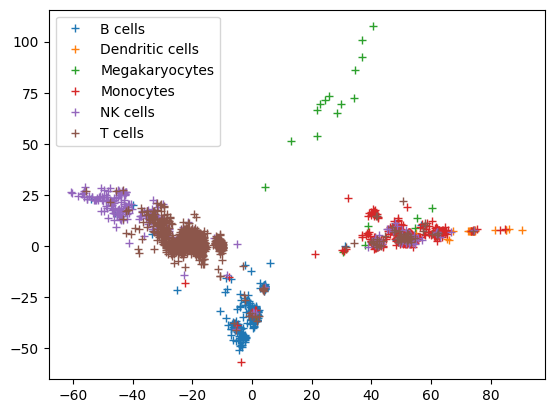

In [30]:
n_neighbor = ns_neighbors[np.argmax(scores)] #identify the optimal number of neighbors that yielded the highest silhouette score
print('Using {} neighbors'.format(n_neighbor))
iso = Isomap(n_components=2, n_neighbors=n_neighbor) #initialize Isomap with the optimal neighbor count
Xiso = iso.fit_transform(Xpca) #fit and transform the PCA-reduced data into the optimized 2D Isomap embedding
f = plt.figure()
ax = f.add_subplot(1,1,1)
for i_label, label in enumerate(labels): #loop through unique classes to scatter plot the embedding points by group
    inds = y_int == i_label #create a boolean mask for samples belonging to the current class
    ax.plot(Xiso[inds,0], Xiso[inds,1], '+', label = label)
plt.legend()

## 4. Dimensionality reduction with tSNE

* Use the TSNE method to project the data over a 2-dimensional space starting from the projection of the data over the first 50 principal components
* Test different values of perplexity and observe how the projection changes

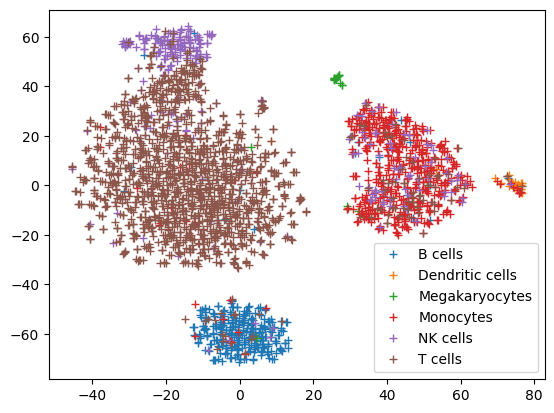

In [31]:
perplexity = 10
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42) #initialize the t-SNE model to project the data into a 2D space with a reproducible seed
Xtsne = tsne.fit_transform(Xpca) #fit the manifold model and transform the PCA-reduced data into the 2D t-SNE embedding
f = plt.figure()
ax = f.add_subplot(1,1,1)
for i_label, label in enumerate(labels): #loop through unique classes to scatter plot the embedding points by group
    inds = y_int == i_label
    ax.plot(Xtsne[inds,0], Xtsne[inds,1], '+', label = label)
plt.legend()

## 4. Dimensionality reduction with UMAP

* Create a conda environment by cloning the base environment (conda create --name NAME_NEW_ENV --clone base)
* Activate the new environment (conda activate NAME_NEW_ENV)
* Install the package umap-learn from the channel conda-forge (conda install -c conda-forge umap-learn
* Import the umap library
* Use the umap method to project the data over a 2-dimensional space starting from the projection of the data over the first 50 principal components
* Test different values of the number of neighbors and observe how the projection changes

In [32]:
import umap

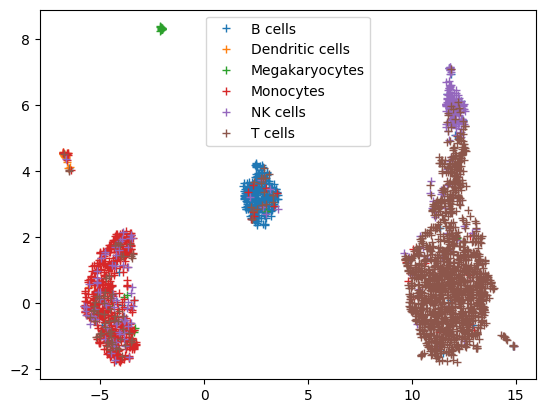

In [33]:
n_neighbors = 4 #same
min_dist = 0.1 # This value was missing and caused the NameError
uma = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42, n_jobs = 1)
Xuma = uma.fit_transform(Xpca)
f = plt.figure()
ax = f.add_subplot(1,1,1)
for i_label, label in enumerate(labels):
    inds = y_int == i_label
    ax.plot(Xuma[inds,0], Xuma[inds,1], '+', label = label)
plt.legend()

## 5. Clustering in the low dimensional space

* Clusterize the data in the low-dimensional space obtained by UMAP with DBSCAN. Optimize the parameters of DBSCAN by looking at the clusterized data in the low-dimensional space
* Use the function imshow to plot an heatmap of gene expression values. Restrict the scale of the heatmap in the range from -0.1 to 0.1
* Order the cells based on the DBSCAN clustering results

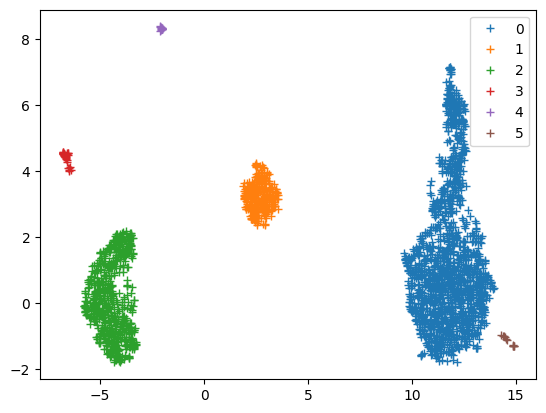

In [36]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.5, min_samples=5).fit(Xuma) #initialize DBSCAN with a maximum neighborhood radius of 0.5 and a minimum of 5 samples per core point
f = plt.figure()
ax = f.add_subplot(1,1,1)
unique_labels = np.unique(model.labels_) #added(?)
n_clusters = len(unique_labels[unique_labels != -1]) #added(?)
for i_label in range(n_clusters): #loop through the expected number of clusters to plot each detected group sequentially
    inds = model.labels_ == i_label
    ax.plot(Xuma[inds,0], Xuma[inds,1], '+', label = i_label)
plt.legend()
inds = model.labels_ == -1 #create a boolean mask specifically to identify unassigned noise points
ax.plot(Xuma[inds,0], Xuma[inds,1], 'xk', label = -1)

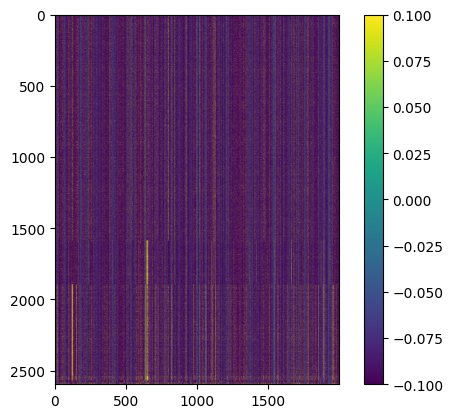

In [37]:
inds = np.argsort(model.labels_) #get the indices that sort the DBSCAN cluster labels in ascending order to group similar points together
plt.imshow(X[inds], cmap="viridis", vmin = -0.1, vmax = 0.1)
plt.colorbar()
plt.show()